In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import pickle

# Veri ve modeli yükle
df = pd.read_csv('../data/customer_summary.csv')
with open('../data/churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Özellikler
X = df[['toplam_siparis', 'toplam_harcama']]
y = df['churn']

print("Yüklendi!")

Yüklendi!


In [3]:
# Logistic Regression için LinearExplainer kullan
explainer = shap.LinearExplainer(model, X)
shap_values = explainer.shap_values(X)

print("SHAP değerleri hesaplandı!")

SHAP değerleri hesaplandı!


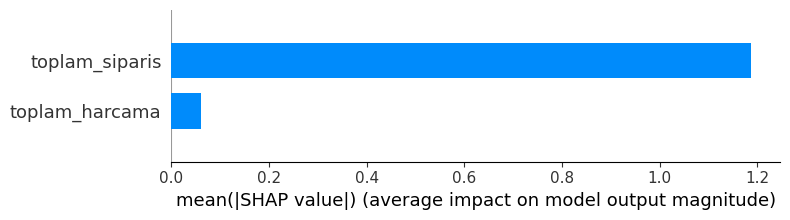

In [4]:
# Genel özellik önem grafiği
shap.summary_plot(shap_values, X, plot_type="bar")

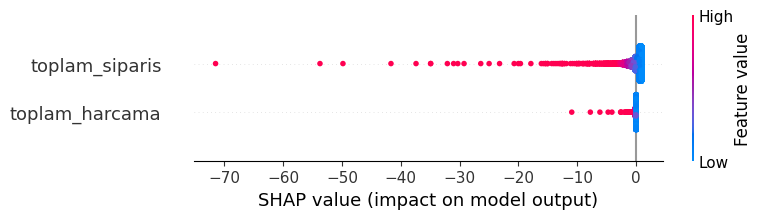

In [5]:
# Detaylı SHAP grafiği — her müşteri için
shap.summary_plot(shap_values, X)

In [ ]:
# En yüksek churn riskli müşteriyi bul
en_riskli_idx = df[df['churn'] == 1].index[0]

# O müşteri için SHAP açıklaması
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[en_riskli_idx],
    X.iloc[en_riskli_idx]
)